> **This notebook was written entirely by Claude** (Anthropic), working from
> the paper and this package's own API. The diagrams below are its output,
> captured from the `tsncd` renderer.
>
> It is here for two reasons. It is a worked example of the whole pipeline -
> algebra, alignment, and rendering - on a model most readers already know.
> And it is evidence that a language model can work in this framework
> productively: the architecture is expressed as one algebraic term, so a model
> writing it has to get the composition and the axis alignment right rather
> than merely produce plausible-looking code, and the diagram makes any mistake
> immediately visible. That the result renders, and that its assertions about
> shapes hold, is the check.


# Attention Is All You Need

Vaswani et al. (2017), assembled as a single morphism in $\mathbf{Br}$.

`Transformer.ipynb` builds the decoder-style stack that most people mean by
"a transformer" today: one tower of masked attention and feed-forward layers.
This notebook builds the architecture the paper actually describes - **two**
towers, with the decoder reading the encoder's output through cross-attention:

| Paper | Here |
| --- | --- |
| Scaled dot-product attention (3.2.1) | `attention_core` |
| Multi-head attention (3.2.2) | `mha` - self, masked-self, and cross |
| Position-wise feed-forward (3.3) | `ffn` |
| Add & Norm (3.1, Fig. 1) | `add_norm` |
| Encoder stack, N = 6 (3.1) | `encoder` |
| Decoder stack, N = 6 (3.1) | `decoder` |
| Embeddings and positional encoding (3.4, 3.5) | `embed` |
| Output linear + softmax (3.4) | `unembed` |

The whole model ends up as one term, from two sequences of token indices to a
distribution over the vocabulary at each target position. Nothing here is
kernelized - this is the expression, before any fusion.

In [1]:
# Locate fix_notebook_dir.py whether the kernel started in this folder or in the
# repository root, then let it put pyncd on the import path. See fix_notebook_dir.py.
import sys; sys.path[:0] = ['.', 'example_notebooks']
import fix_notebook_dir

In [2]:
import contextlib
import io
from IPython.display import display

import construction_helpers as ch  # Needed for @ auto-alignment
import data_structure.Category as cat
import data_structure.Operators as ops
import data_structure.Term as fd
import display as dpl
import term_utilities.generate_config as gc
import websocket_transfer.capture as capture
import websocket_transfer.send_morphism as sending
import websocket_transfer.websockets_transfer as wst

# How diagrams are delivered.
#   'inline'  - capture the drawing back and embed it in the cell output, so it
#               is saved with the notebook. A few seconds each, nearly all of it
#               the browser laying the diagram out.
#   'browser' - push it to the open tsncd page and move on, ~15 ms. What to work
#               in; nothing is embedded.
#   'off'     - skip them. `display.print_category(term)` still gives a text
#               rendering, which is also what to reach for from an agent.
# Either of the first two needs `python run_server.py` and a tsncd page open.
DIAGRAMS = 'inline'


async def show(term, caption=None, width=None):
    '''Draw a term, per DIAGRAMS. `width` sets the wrap width, so it sets the
    figure's proportions rather than its scale - wide terms want more.'''
    if caption:
        print(caption)
    if DIAGRAMS == 'off':
        dpl.print_category(term)
        return
    try:
        # The round trip's chatter is not interesting, but the text fallback is,
        # so it is turned off here and taken below - outside the redirect that
        # would otherwise swallow it.
        with contextlib.redirect_stdout(io.StringIO()):
            image = (await capture.capture_morphism(
                         term, width=width, timeout=120, print_fallback=False)
                     if DIAGRAMS == 'inline'
                     else await sending.send_morphism(term, width=width))
    except (OSError, wst.CaptureError) as error:
        print(f'(no diagram: {error})')
        dpl.print_category(term)
        return
    if image is not None:
        display(image)

## Axes and objects

Five axes carry the whole model: `x` source positions, `y` target positions,
`m` = $d_\text{model}$, `h` heads, `k` = $d_k$, plus $d_\text{ff}$ inside the
feed-forward layer.

The one thing `@` cannot infer is that **`x` and `y` are different axes**.
Composition aligns the codomain of the left morphism against the domain of the
right, and when it finds a shorter shape on one side it lifts *the whole
product* by the excess taken from its first object - which is exactly right
when every input shares a batch axis, and exactly wrong for cross-attention,
where the queries are indexed by target position and the keys by source
position. Left alone, alignment would merge the two into one axis and quietly
force the source and target lengths to be equal.

So we name the two sequence axes up front and lift by hand with `>>` wherever
the automatic rule would guess wrong. Names being decoration, the check that
this worked is on UIDs, not letters.

In [3]:
R = cat.Reals()

m = cat.RawAxis.named('m')      # d_model
src = cat.RawAxis.named('x')    # source positions
tgt = cat.RawAxis.named('y')    # target positions

vocab = fd.DynamicName('v', settings=fd.DynamicNameSettings(overline=True))

memory = cat.Array(R, (src, m))   # what the encoder hands to the decoder
state = cat.Array(R, (tgt, m))    # what flows down the decoder


def hold(obj):
    '''The identity on a single object - a wire that passes straight through.'''
    return cat.ProdObject((obj,)).identity()


def axis_name(axis):
    return axis.uid._name.to_bodies() if axis.uid._name else '?'


def axes(morphism):
    '''Axis names of the domain and codomain, for checking shapes by eye.'''
    def names(objs):
        return [[axis_name(a) for a in o.shape()] for o in objs]
    return names(morphism.dom()), names(morphism.cod())

## Scaled dot-product attention

$$\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}}\right)V$$

Two contractions with a softmax between them. The first einsum contracts `k`
and leaves the score matrix tiled over `h`, `q`, `x`; the second contracts the
`x` of the scores against the `x` of the values.

Masking follows the package's existing attention examples and sits *after* the
softmax, as a weighted lower-triangular map. The paper masks the logits
themselves; move `WeightedTriangularLower` above `SoftMax` if you want that
reading instead.

Masked scaled dot-product attention: queries and keys in at the top, values at the bottom.


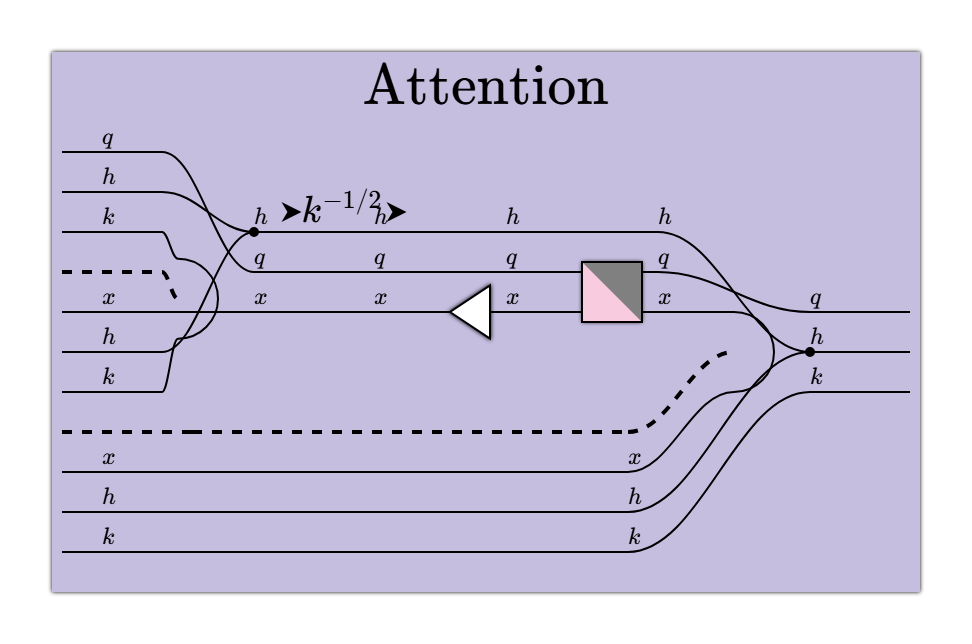

In [4]:
def attention_core(masked=False):
    body = (
        ops.Einops.template('q h k, x h k -> h q x')
        @ ops.Elementwise.template(name='k^{-1/2}')
        @ ops.SoftMax.template()
    )
    if masked:
        body = body @ ops.WeightedTriangularLower.template()
    return cat.Block.template(
        body @ ops.Einops.template('h q x, x h k -> q h k'),
        title='Attention', fill_color='#C5BEDF'
    )


await show(attention_core(masked=True),
           'Masked scaled dot-product attention: queries and keys in at the top, '
           'values at the bottom.')

## Multi-head attention

Three projections into `(h, k)`, the attention core, and one projection back to
`m`. Only the wiring in front distinguishes the paper's three uses of the
block:

- **self-attention** copies one input three ways - `(0, 0, 0)`;
- **cross-attention** takes queries from the decoder and keys and values from
  the encoder - `(0, 1, 1)`.

Each projection is lifted onto the sequence axis it belongs to *before* the
core sees it. For self-attention that is one axis three times and the merge
that alignment would have performed anyway; for cross-attention it is `y` for
the query and `x` for the keys and values, which keeps the two lengths apart.

Self-attention: one wire in, copied three ways.


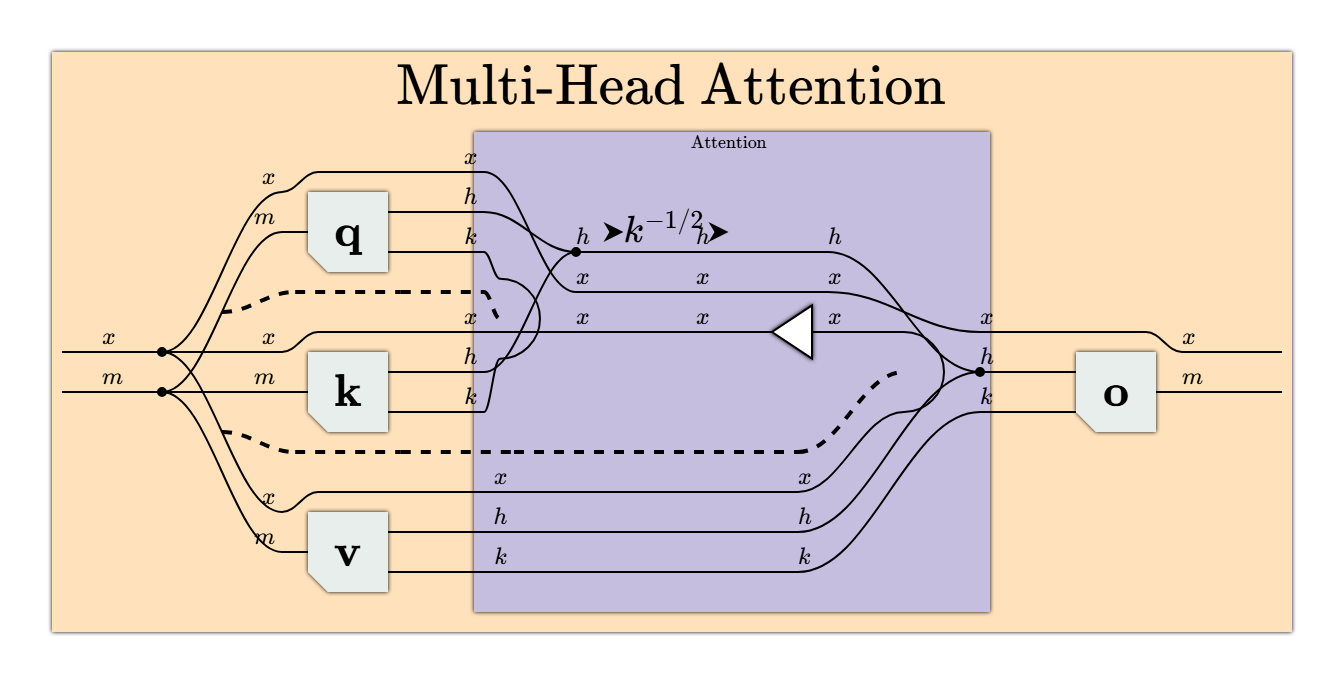

In [5]:
def mha(q_axis, kv_axis=None, masked=False, title='Multi-Head Attention'):
    cross = kv_axis is not None
    kv_axis = kv_axis if cross else q_axis
    return cat.Block.template(
        ((0, 1, 1) if cross else (0, 0, 0))
        @ ((q_axis >> ops.Linear.template('m', ('h', 'k'), 'q'))
           * (kv_axis >> ops.Linear.template('m', ('h', 'k'), 'k'))
           * (kv_axis >> ops.Linear.template('m', ('h', 'k'), 'v')))
        @ attention_core(masked)
        @ ops.Linear.template(('h', 'k'), 'm', 'o'),
        title=title, fill_color='#FFE2BB'
    )


await show(mha(src), 'Self-attention: one wire in, copied three ways.')

Cross-attention: the query wire and the key/value wire arrive separately.


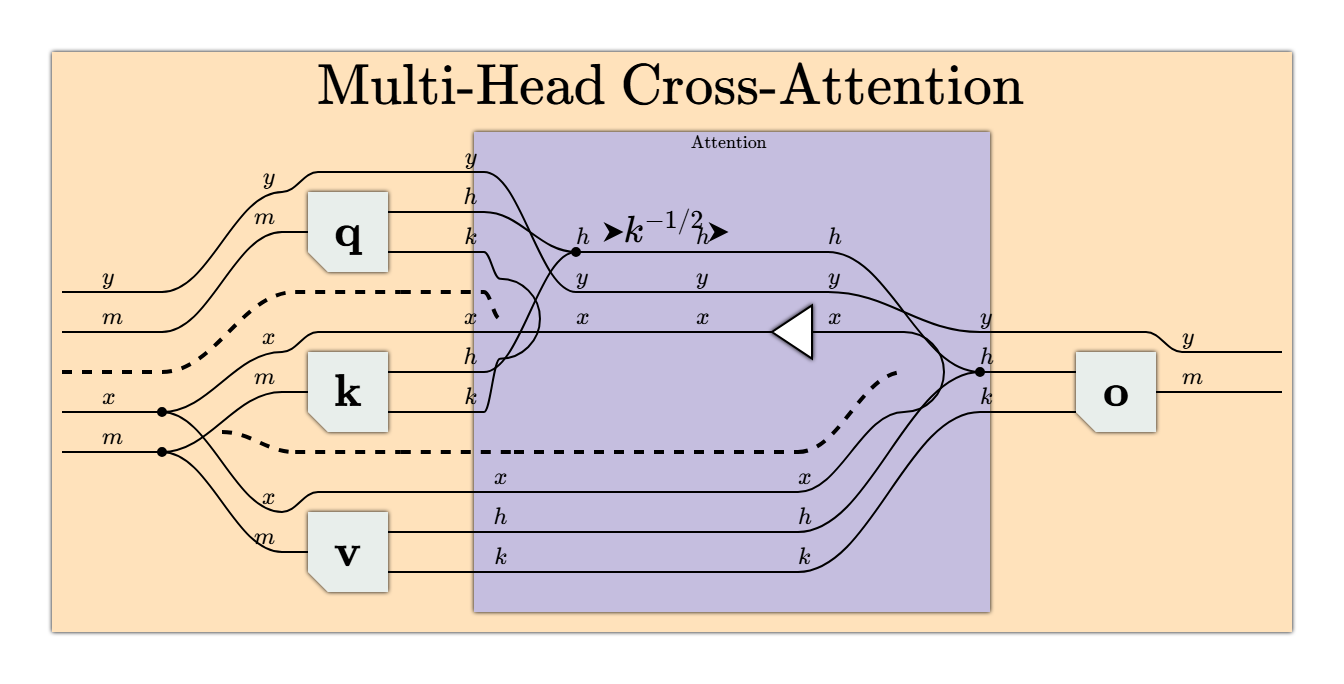

In [6]:
await show(mha(tgt, src, title='Multi-Head Cross-Attention'),
           'Cross-attention: the query wire and the key/value wire arrive separately.')

The two really are distinct axes, not merely two letters:

In [7]:
cross_attention = mha(tgt, src)
q_axis, kv_axis = (o.shape()[0] for o in cross_attention.dom())
assert q_axis != kv_axis, 'source and target lengths have been merged'
print(f'queries indexed by {axis_name(q_axis)}, '
      f'keys and values by {axis_name(kv_axis)}')

queries indexed by y, keys and values by x


## Position-wise feed-forward

$$\text{FFN}(z) = \max(0, zW_1 + b_1)W_2 + b_2$$

Written on a single position and lifted onto the sequence axis, which is what
"position-wise" means: the same map at every index.

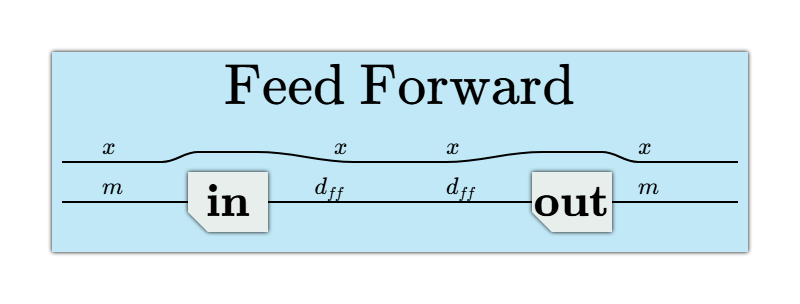

In [8]:
def ffn(axis):
    return axis >> cat.Block.template(
        ops.Linear.template('m', ('d_ff',), 'in')
        @ ops.ReLU.template(name='ReLU')
        @ ops.Linear.template(('d_ff',), 'm', 'out'),
        title='Feed Forward', fill_color='#C1E8F7'
    )


await show(ffn(src))

## Add & Norm

Every sublayer is wrapped as $\text{Norm}(z + \text{Sublayer}(z))$. The wrapper
is a rearrangement that fans the domain out into *the sublayer's inputs, then
the residual copy, then anything merely passing through*, and the passengers
have to be spelled out as identity wires so that the rearrangement lands on
something of the right width.

That trailing "passing through" is what makes the decoder work. Its layers
consume `(state, memory)` and must return `(state, memory)` for the stack to
repeat, so the encoder's output rides alongside every sublayer:

| Sublayer | Domain | Mapping |
| --- | --- | --- |
| Encoder self-attention, encoder FFN | `(memory,)` | `(0, 0)` |
| Decoder masked self-attention, decoder FFN | `(state, memory)` | `(0, 0, 1)` |
| Decoder cross-attention | `(state, memory)` | `(0, 1, 0, 1)` |

The residual copy leaves before the sublayer and rejoins at the addition.


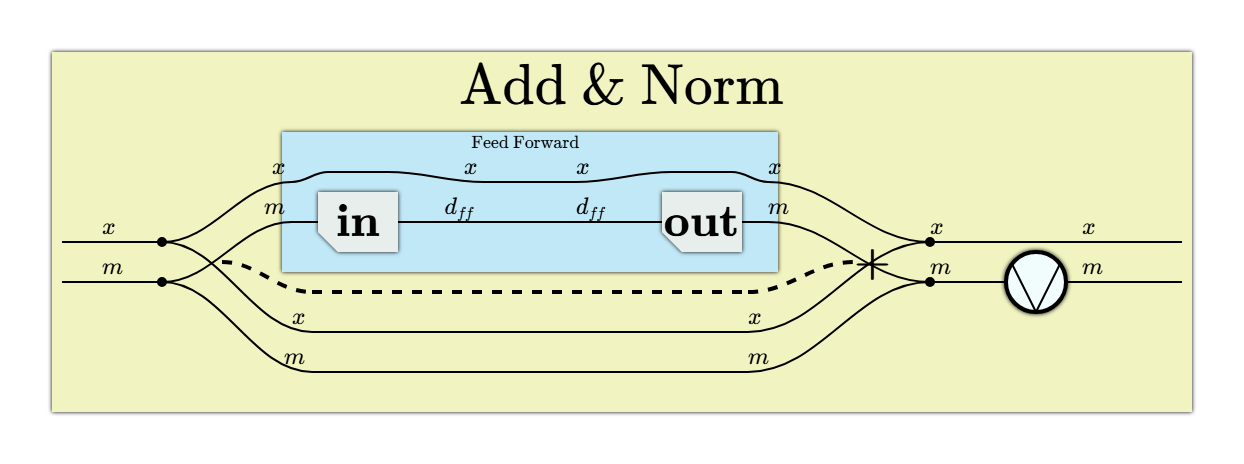

In [9]:
def add_norm(body, dom, mapping):
    padded = body
    for i in mapping[len(body.dom()):]:
        padded = padded * hold(dom[i])
    return cat.Block.template(
        cat.Rearrangement(mapping, tuple(dom))
        @ padded
        @ ops.AdditionOp.template()
        @ ops.Normalize.template(),
        title='Add \\& Norm', fill_color='#F1F4C1'
    )


await show(add_norm(ffn(src), (memory,), (0, 0)),
           'The residual copy leaves before the sublayer and rejoins at the addition.')

## The encoder

Self-attention, then feed-forward, each wrapped in Add & Norm - one object in,
one object out, six times over.

([['x', 'm']], [['x', 'm']])


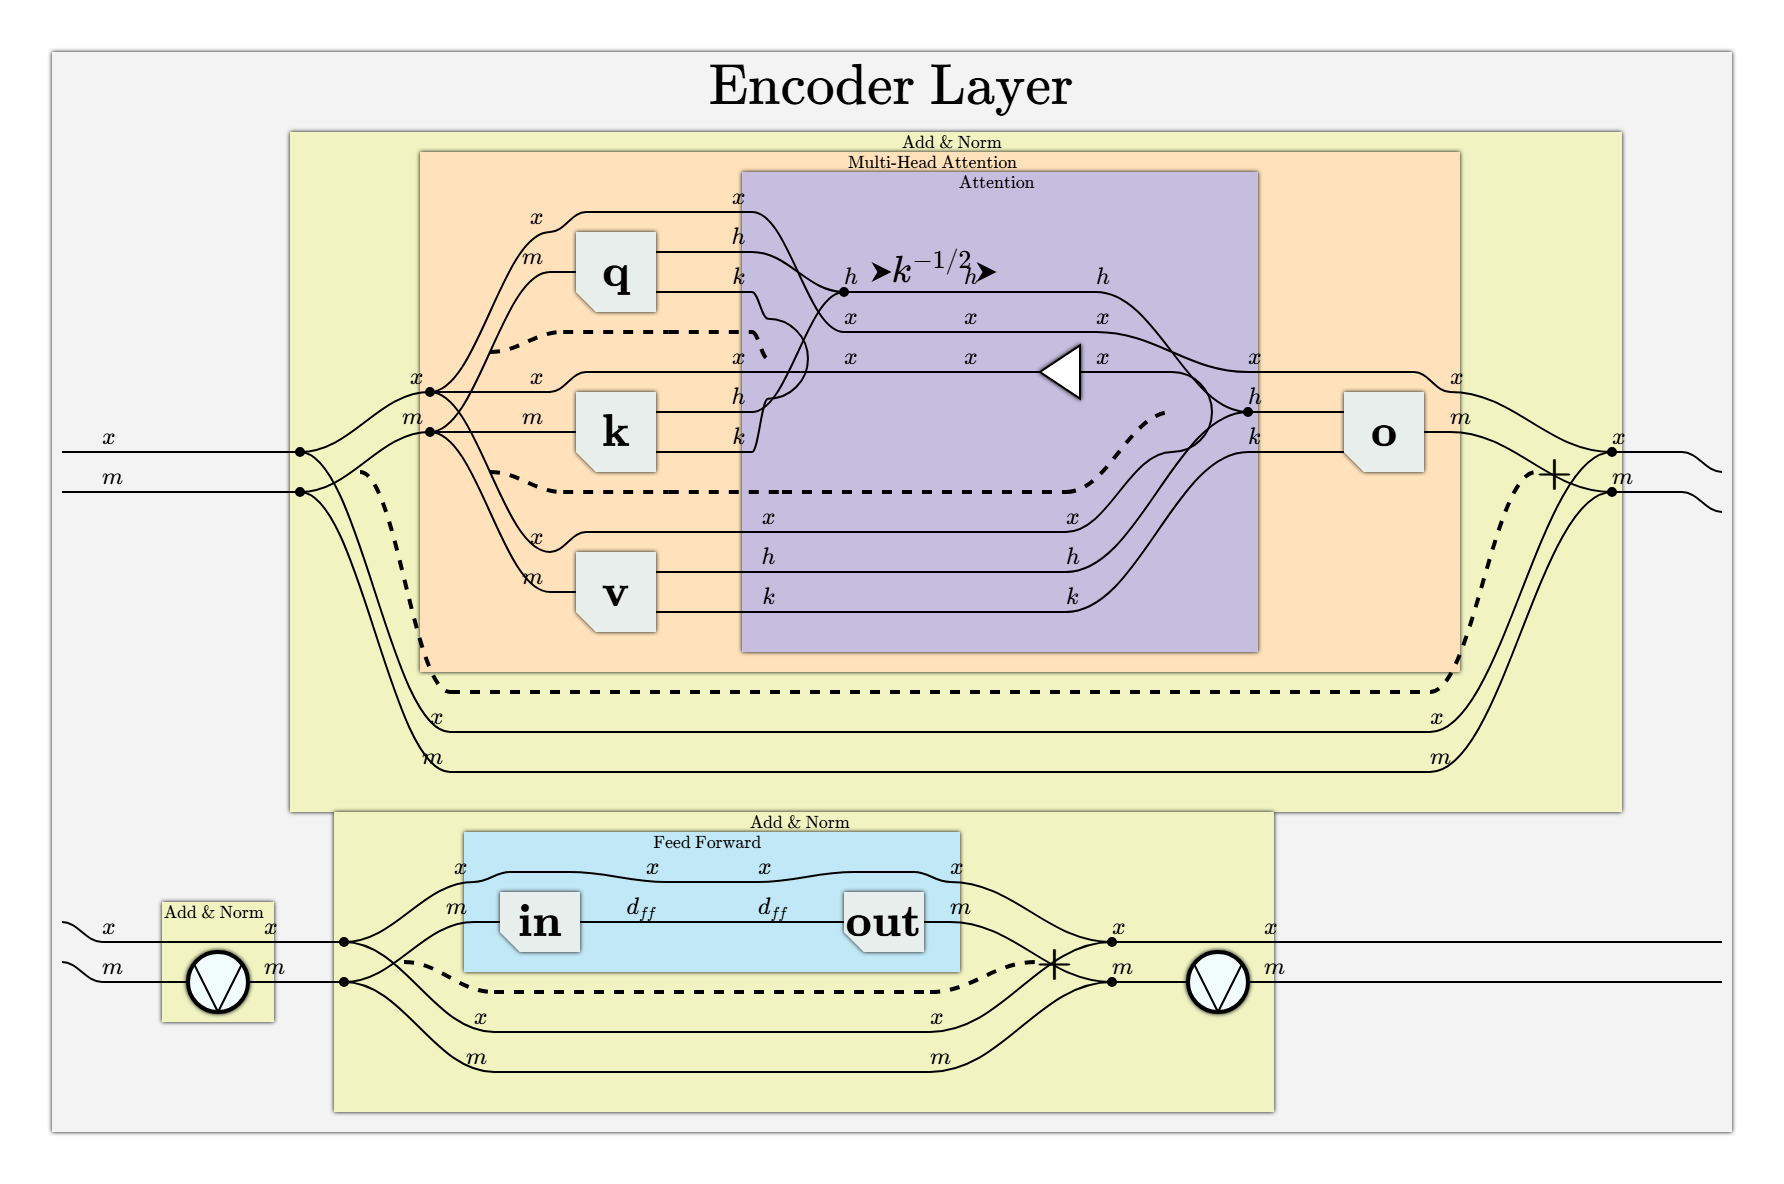

In [10]:
N = 6

encoder = cat.Block.template(
    add_norm(mha(src), (memory,), (0, 0))
    @ add_norm(ffn(src), (memory,), (0, 0)),
    title='Encoder Layer', repetition=N, fill_color='#F3F3F4'
)

assert encoder.dom() == encoder.cod(), 'a repeated block must return its own domain'
print(axes(encoder))
await show(encoder)

## The decoder

Three sublayers instead of two: masked self-attention over the target, then
cross-attention into the encoder's output, then the feed-forward. The `memory`
wire enters at the top of every layer and leaves untouched at the bottom.

([['y', 'm'], ['x', 'm']], [['y', 'm'], ['x', 'm']])


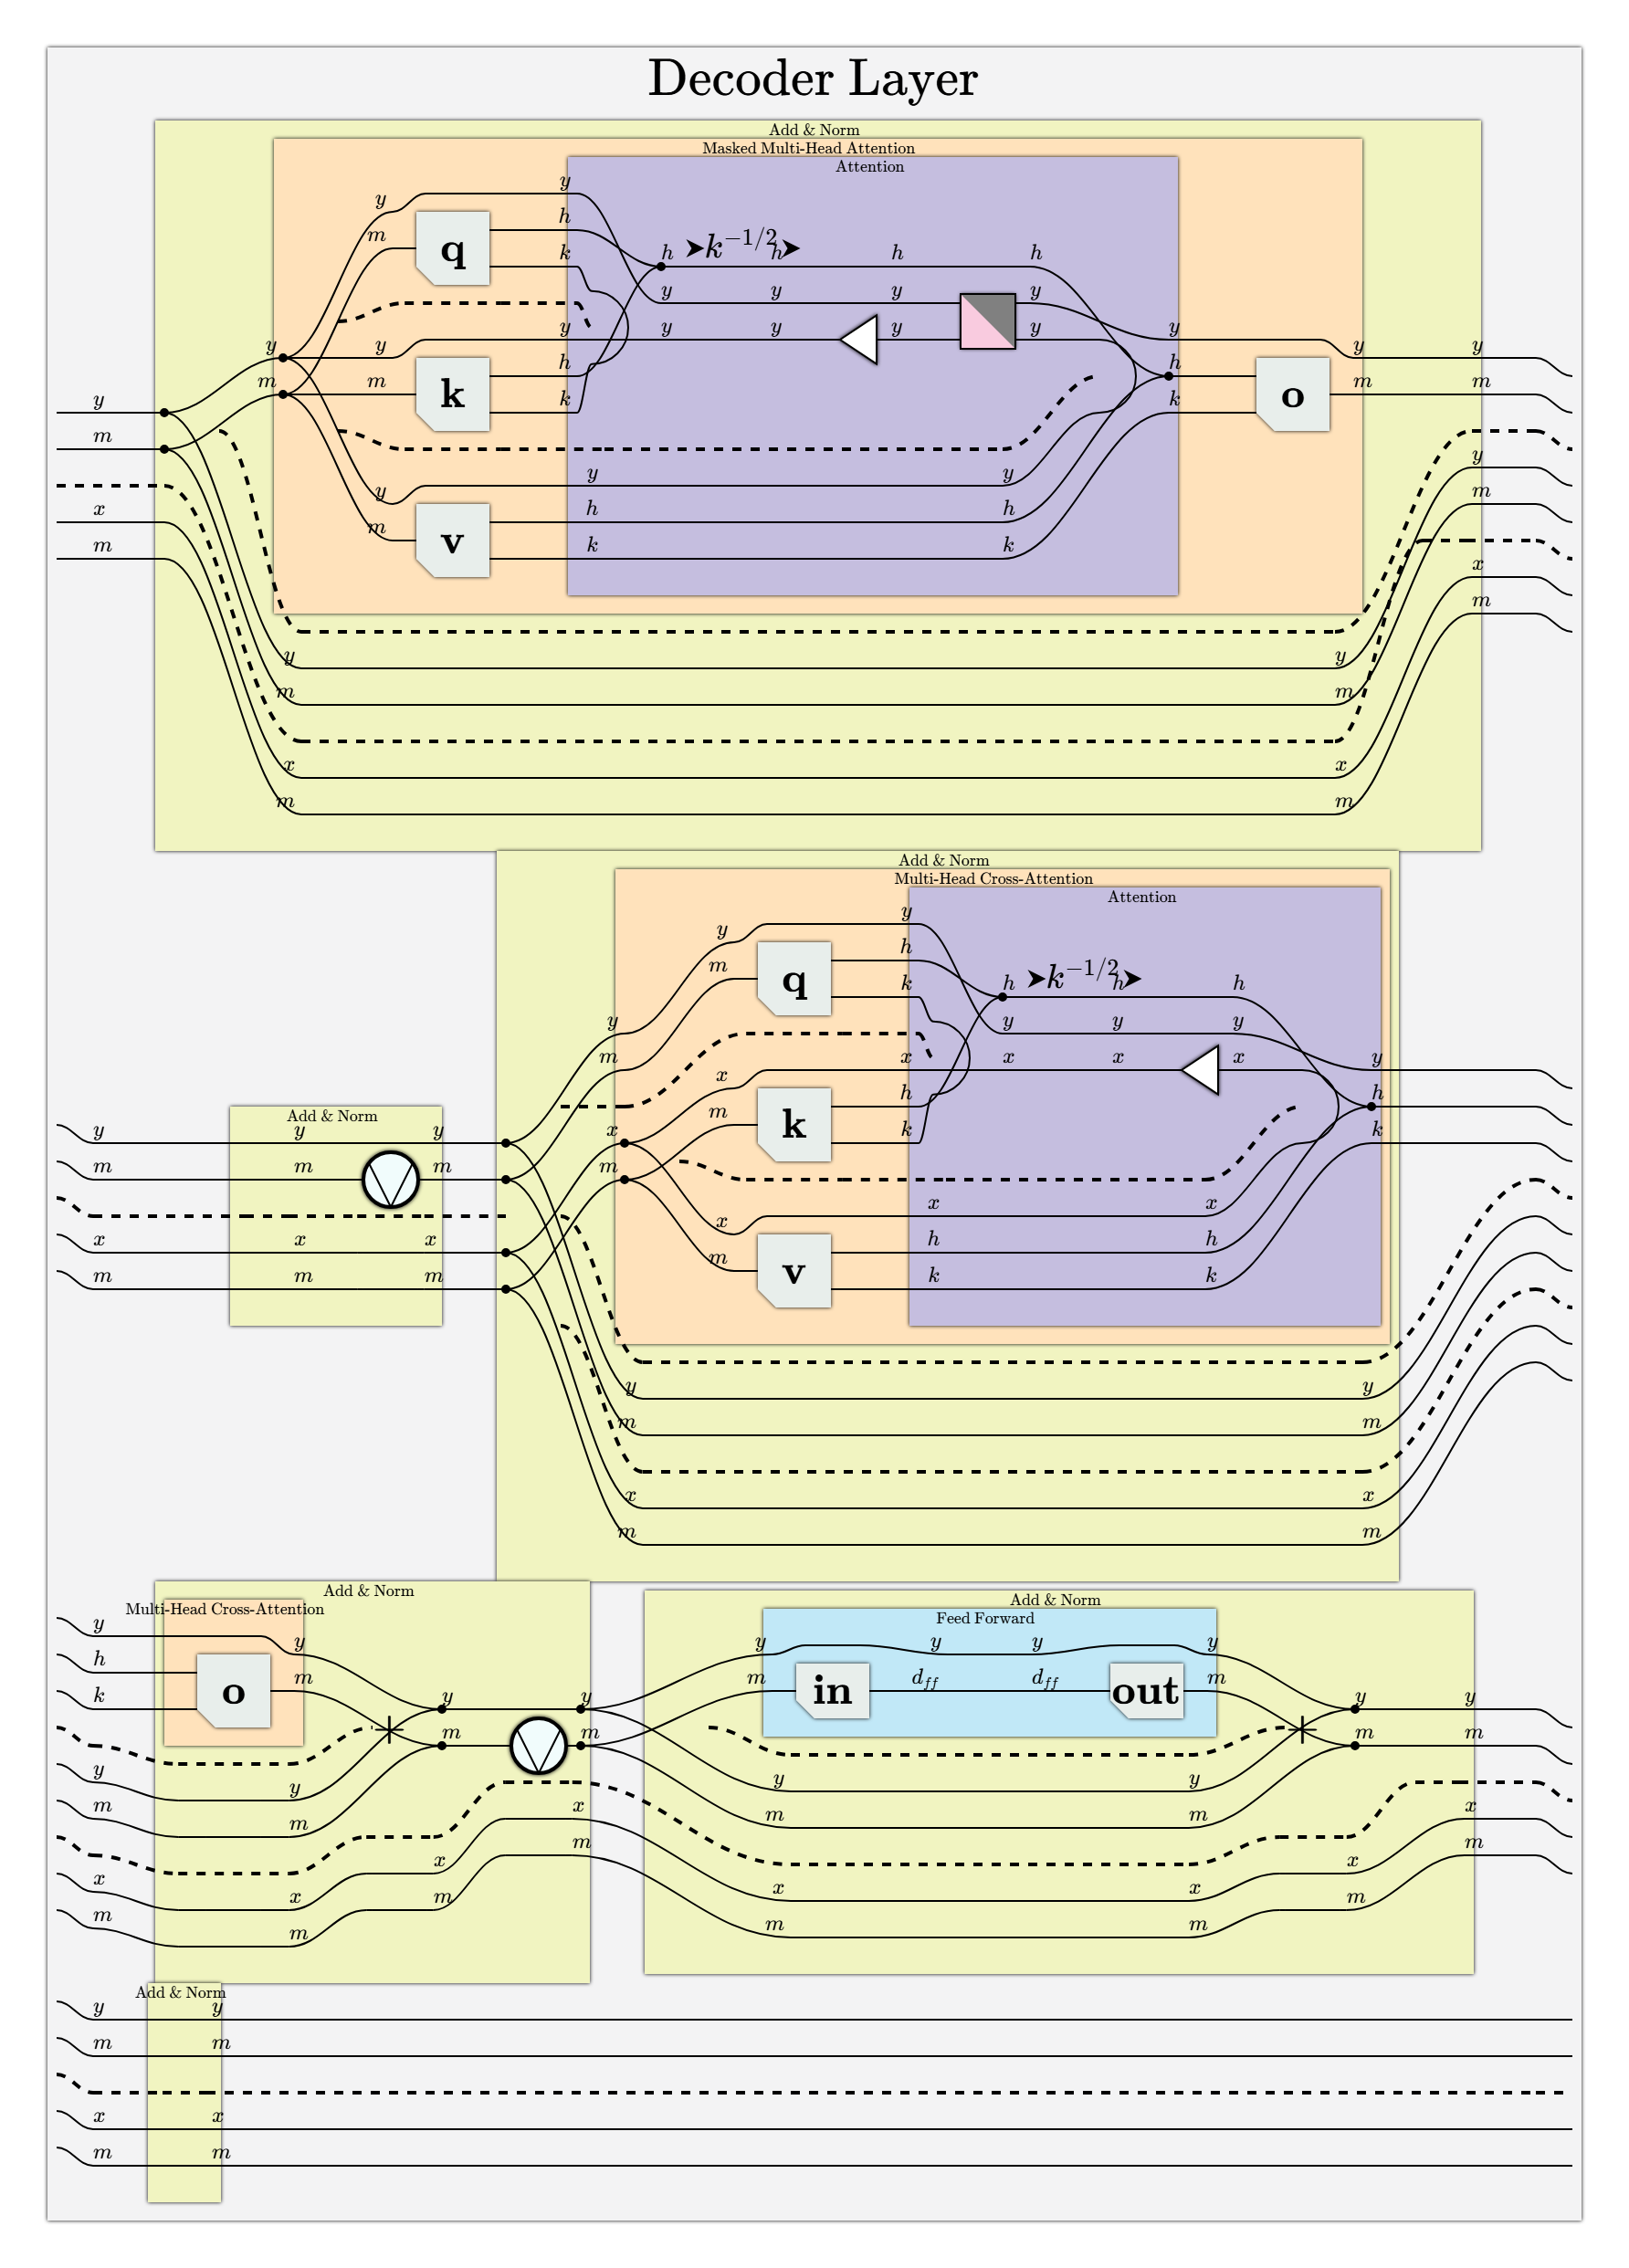

In [11]:
dec_dom = (state, memory)

decoder = cat.Block.template(
    add_norm(mha(tgt, masked=True, title='Masked Multi-Head Attention'),
             dec_dom, (0, 0, 1))
    @ add_norm(mha(tgt, src, title='Multi-Head Cross-Attention'),
               dec_dom, (0, 1, 0, 1))
    @ add_norm(ffn(tgt), dec_dom, (0, 0, 1)),
    title='Decoder Layer', repetition=N, fill_color='#F3F3F4'
)

assert decoder.dom() == decoder.cod(), 'a repeated block must return its own domain'
print(axes(decoder))
await show(decoder)

## Embeddings, positional encoding, and the output head

The embedding maps a token index - an element of $\mathbb{N}_{\bar v}$ - to a
vector of width `m`, and the positional encoding adds the sinusoidal table on
top.

`PE` is written as an operator over the *whole* `(x, m)` array rather than a
broadcast over positions, and that is deliberate. A tiled operator is by
definition the same function at every index, and the positional encoding is
precisely a function *of* the index; the axis it varies along has to belong to
the target, exactly as the sequence axes belong to the target of the triangular
mask. The addition is inside the operator rather than drawn as a separate
$\oplus$, since there is no value-carrying wire for the other summand to arrive
on.

embed   ([['x']], [['x', 'm']])
unembed ([['m']], [['v']])
Embedding straight into the output head, to see both ends at once.


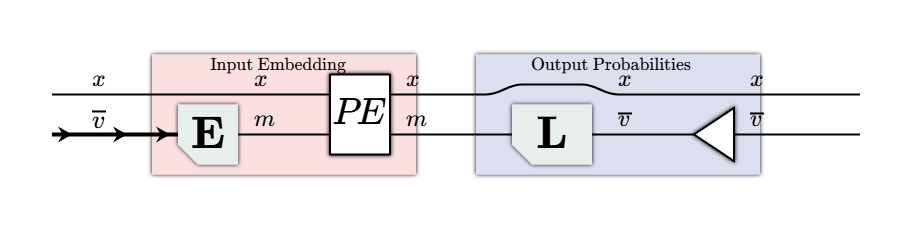

In [12]:
def embed(axis, title):
    return cat.Block.template(
        ops.Embedding.template(vocab)
        @ ops.sized(ops.GenericOperator(fd.DynamicName('PE')), (axis, m)),
        title=title, fill_color='#FCE0E1'
    )


unembed = cat.Block.template(
    ops.Linear.template('m', (vocab,)) @ ops.SoftMax.template(),
    title='Output Probabilities', fill_color='#DBDFEF'
)

print('embed  ', axes(embed(src, 'Input Embedding')))
print('unembed', axes(unembed))
await show(embed(src, 'Input Embedding') @ unembed,
           'Embedding straight into the output head, to see both ends at once.')

## The whole model

Both sequences are embedded, the encoder runs on the source while the embedded
target waits its turn, a swap puts the decoder's state on top of its memory,
the decoder stack runs, and the memory is dropped before the output head.

In [13]:
transformer = (
    (embed(src, 'Input Embedding') * embed(tgt, 'Output Embedding'))
    @ encoder
    @ cat.Rearrangement((1, 0), (memory, state))   # -> (state, memory)
    @ decoder
    @ cat.Rearrangement((0,), (state, memory))     # drop the memory
    @ unembed
)

print(axes(transformer))

([['x'], ['y']], [['y', 'v']])


Two sequences of token indices in, one distribution per target position out:

In [14]:
source, target = transformer.dom()
probabilities, = transformer.cod()

assert isinstance(source.datatype, cat.Natural) and isinstance(target.datatype, cat.Natural)
assert isinstance(probabilities.datatype, cat.Reals)
assert source.shape()[0] != target.shape()[0], 'source and target lengths are independent'

print(f'dom: {len(transformer.dom())} objects, cod: {len(transformer.cod())} object')
print(f'out: {[axis_name(a) for a in probabilities.shape()]}')

dom: 2 objects, cod: 1 object
out: ['y', 'v']


## Base model dimensions

Table 3, row *base*: $d_\text{model} = 512$, $h = 8$, $d_k = d_v = 64$,
$d_\text{ff} = 2048$, $N = 6$. `d_ff` parses as $d$ subscript $ff$, so it is
`d` that gets assigned.

In [15]:
config = gc.NumericConfig.template(transformer)
config.assign_values(m=512, h=8, k=64, d=2048)

transformer_base = config(transformer)
print(sorted({t.uid._name.to_bodies() for t in config.terms if t.uid._name}))

['dff', 'h', 'k', 'm', 'v', 'x', 'y']


## The model

The encoder tower comes first, the decoder second, and the wire running from
one to the other is the memory that every cross-attention block reads. It wraps
at `show`'s default width; pass a larger `width` for a flatter figure.

A caution on operator names: they are rendered as LaTeX by the browser, and the
renderer takes a *subset* of it. Superscripts and simple macros are fine -
`k^{-1/2}` above, `\sigma`, `\lightning` - but `\frac` fails the capture
outright and `\sqrt` lays out to some 8000px, which silently truncates the
figure at the renderer's 16384px ceiling and loses whatever sat on its right.

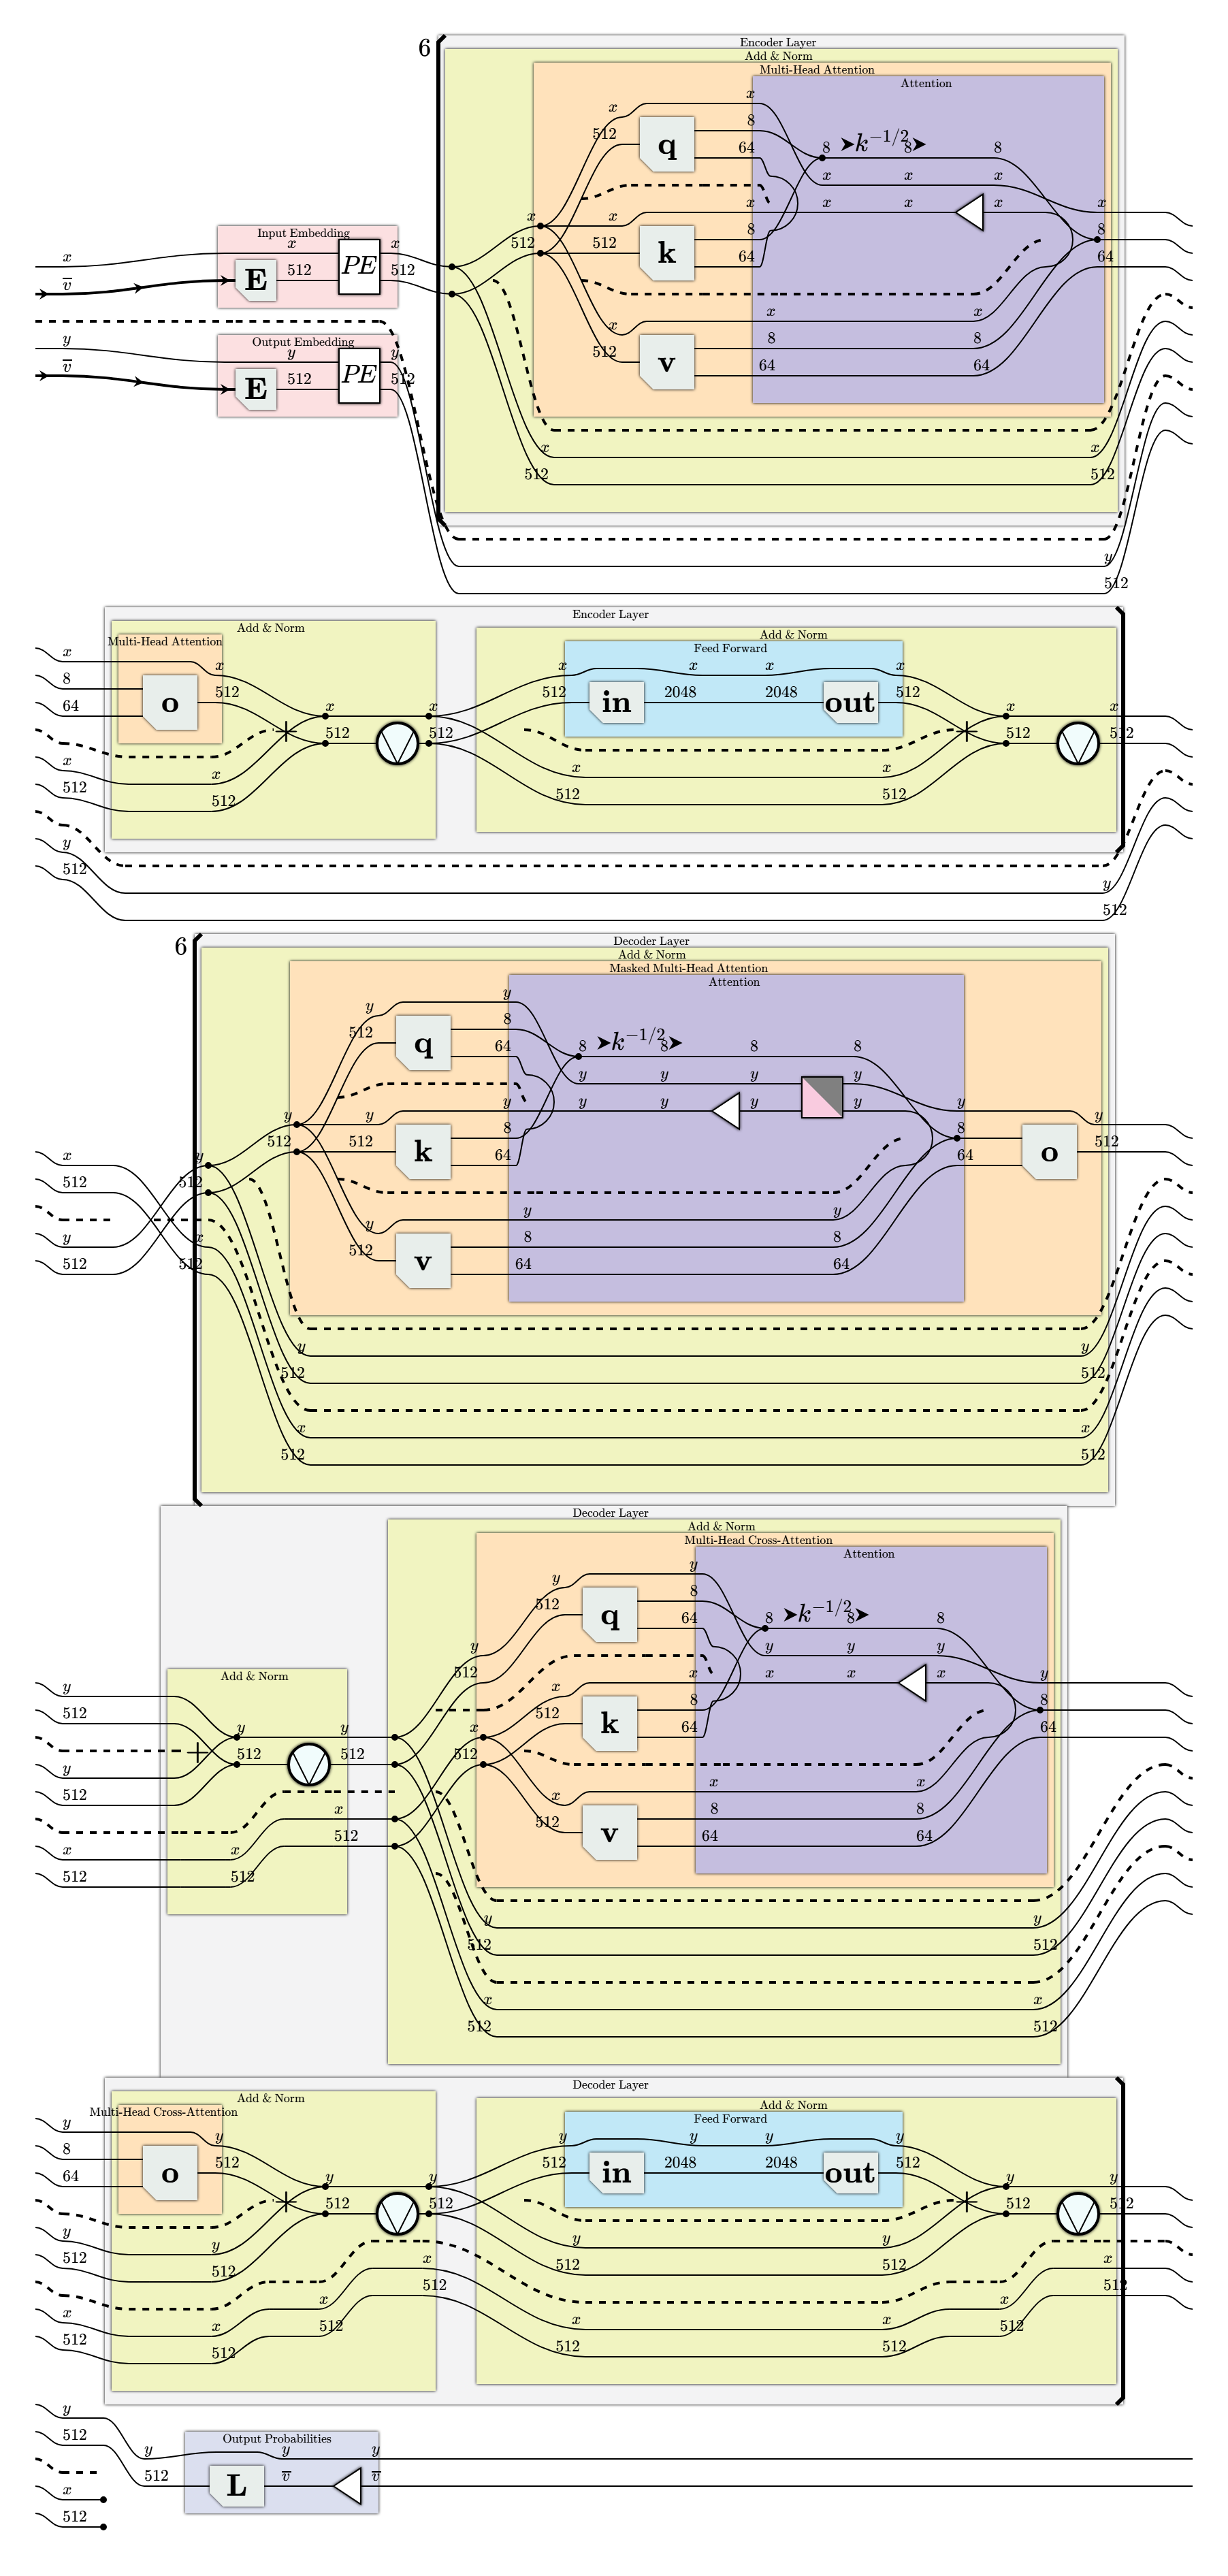

In [16]:
await show(transformer_base)

## What is left out

Structural things the paper specifies that this term does not say:

- **Dropout** (5.4) - residual, attention, and embedding dropout. `ops.Dropout`
  exists if you want them drawn.
- **Weight sharing** (3.4) - the two embeddings and the output projection share
  a matrix, and the embedding is scaled by $\sqrt{d_\text{model}}$. Every
  `Linear` here is its own operator.
- **Layer norm placement** - this is the paper's post-norm arrangement, kept as
  written rather than the pre-norm variant everything since has used.
- **Normalization** - `ops.Normalize` is RMSNorm, not the paper's LayerNorm.
- **Training** (5.3, 5.4) - warmup schedule, label smoothing, beam search.